In [3]:
import waveletec as wEC
import xarray as xr

wEC.run_from_eddypro(
    path="input/EP/FR-Gri_sample.eddypro",
    output_folderpath="output/wavelet_flux",
    datetimerange="20220513T0000-20220516T0000",
    processing_time_duration="3h",
    covariance=["w*co2|w*h2o"],
)
print("Done.")

Done.


In [ ]:
wcollection = type('var_', (object,), {})
wcollection.data = (wEC.open_files_in_folder(
    'output/wavelet_flux/wavelet_full_cospectra')
    .sortby('TIMESTAMP')
    .drop_duplicates('TIMESTAMP'))
wcollection.time = wEC.data_integrate_in_frequency(wcollection.data, 1/(30*60))
wcollection.parr = wEC.data_partition(wcollection.data)
wcollection.part = wEC.data_partition(wcollection.time)

wcollection.time = wcollection.time.rename(
    {var: f"{var}_int" for var in wcollection.time.data_vars})
wcollection.parr = wcollection.parr.rename(
    {var: f"{var}~" for var in wcollection.parr.data_vars})
wdata = xr.merge([wcollection.data, wcollection.time,
                 wcollection.parr, wcollection.part],
                 compat='override')

wdata['TIME'] = wdata.TIMESTAMP.dt.hour + wdata.TIMESTAMP.dt.minute / 60
wdata = wdata.set_coords('TIME')
wdata['DATE'] = wdata.TIMESTAMP.dt.date
wdata = wdata.set_coords('DATE')

wcollection.time.to_netcdf(
    "output/wavelet_flux/FR-Gri_sample_CDWT_full_cospectra.nc")
wcollection.part.to_netcdf(
    "output/wavelet_flux/FR-Gri_sample_CDWT_partitioning.nc",
)

flxnet = wEC.io.READERS.get('fluxnet')(
    'output/eddypro_FR-Gri_sample_fluxnet_2024-04-24T111754_adv.csv').sortby('TIMESTAMP')

In [42]:
for var in [c for c in wdata.data_vars if c.startswith('wco2')] + ['NEE', 'GPP', 'Reco']:
    corr = (1 / flxnet.DRYAIR_MV)
    wdata[f'F_UNCORR_{var}'] = wdata[var] * corr
    wdata[f'F_{var}'] = wdata[var] * \
        corr * flxnet.FC_SCF
    
for var in [c for c in wdata.data_vars if c.startswith('wts')]:
    corr = flxnet.AIR_DENSITY * flxnet.AIR_CP
    wdata[f'F_UNCORR_{var}'] = wdata[var] * corr
    wdata[f'F_{var}'] = wdata[var] * \
        corr * flxnet.H_SCF
    
for var in [c for c in wdata.data_vars if c.startswith('wh2o')]:
    corr = 10**-3 * \
            (10**3 * (3147.5 - 2.37 * flxnet.TA_EP)) * \
            0.01802 / flxnet.DRYAIR_MV
    wdata[f'F_UNCORR_{var}'] = wdata[var] * corr
    wdata[f'F_{var}'] = wdata[var] * \
        corr * flxnet.LE_SCF

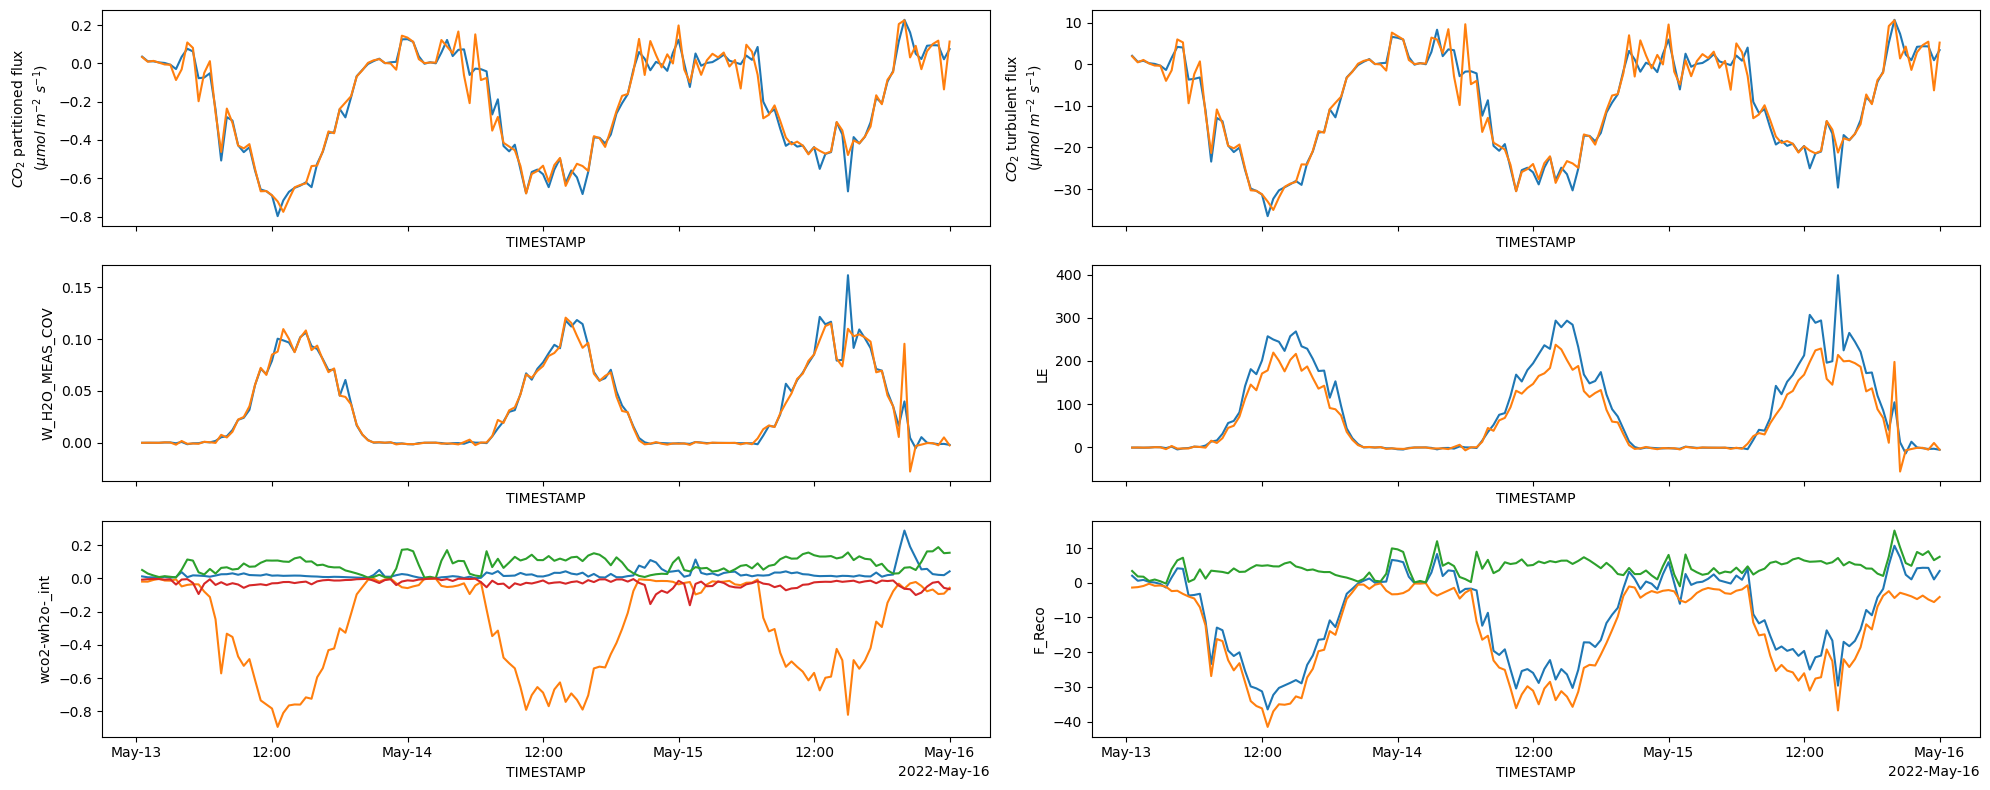

In [43]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(3, 2, figsize=(20, 8), sharex=True)

wdata['wco2_int'].plot(label='WL', ax=ax[0, 0])
flxnet['W_CO2_MEAS_COV'].plot(label='EP', ax=ax[0, 0])
ax[0, 0].set_ylabel(
    r"$\overline{w'CO_2'}$" + "\n" + r"($ppm\ m\ s^{-1}$)")

wdata['F_wco2_int'].plot(label='WL', ax=ax[0, 1])
flxnet['FC'].plot(label='EP', ax=ax[0, 1])
ax[0, 1].set_ylabel(
    r'$CO_2$ turbulent flux' + '\n' + r'($μmol\ m^{-2}\ s^{-1}$)')


wdata['wh2o_int'].plot(label='WL', ax=ax[1, 0])
flxnet['W_H2O_MEAS_COV'].plot(label='EP', ax=ax[1, 0])
ax[0, 0].set_ylabel(
    r"$\overline{w'H_2O'}$" + "\n" + r"($ppt\ m\ s^{-1}$)")

wdata['F_wh2o_int'].plot(label='WL', ax=ax[1, 1])
flxnet['LE'].plot(label='EP', ax=ax[1, 1])
ax[0, 1].set_ylabel(
    r'$H_2O$ turbulent flux' + '\n' + r'($mmol\ m^{-2}\ s^{-1}$)')


wdata['wco2+wh2o+_int'].plot(label='++', ax=ax[2, 0])
wdata['wco2-wh2o+_int'].plot(label='-+', ax=ax[2, 0])
wdata['wco2+wh2o-_int'].plot(label='+-', ax=ax[2, 0])
wdata['wco2-wh2o-_int'].plot(label='--', ax=ax[2, 0])
ax[0, 0].set_ylabel(
    r'$CO_2$ partitioned flux' + '\n' + r'($μmol\ m^{-2}\ s^{-1}$)')

wdata['F_NEE'].plot(label='GPP', ax=ax[2, 1])
wdata['F_GPP'].plot(label='GPP', ax=ax[2, 1])
wdata['F_Reco'].plot(label='Reco', ax=ax[2, 1])
ax[0, 1].set_ylabel(
    r'$CO_2$ turbulent flux' + '\n' + r'($μmol\ m^{-2}\ s^{-1}$)')

plt.tight_layout()
plt.show()